# Regular 1

| | |
|---|---|
| Thời gian | 90 phút |
| Hình thức | Làm trực tiếp trên notebook này. Không xóa đề. |

### Rules
1. Import các thư viện đã học.
2. Mọi nhận xét viết ngắn gọn, dựa trên kết quả vừa tính — không copy insight có sẵn.
3. Chạy cell theo thứ tự từ trên xuống.
4. Biểu đồ phải có title và nhãn trục. In kết quả số ra màn hình.

### Bảng điểm tóm tắt

| Phần | Nội dung | Điểm |
|---|---|---|
| 0 | Import, load | không tính điểm |
| 1 | Inspection | 2,5 |
| 2 | Data cleaning (missing, dtype, feature) | 3,5 |
| 3 | EDA (Univariate & Multivariate) | 3,0 |
| 4 | Summary & insights | 1,0 |
| **Tổng** | | **10,0** |
| Bonus | | +2,0 |
| **Tối đa** | | **12,0** |


# Import thư viện


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# Dataset Description

Cột gốc (file CSV):

- show_id: mã từng title
- type: Movie hoặc TV Show
- title: tên phim hoặc chương trình
- director: đạo diễn
- cast: diễn viên
- country: quốc gia sản xuất; 
- date_added: ngày thêm 
- release_year: năm phát hành gốc
- rating: xếp hạng độ tuổi
- duration: thời lượng dạng chữ. Movie là phút (90 min), TV Show là số mùa (2 Seasons)
- listed_in: thể loại; có thể nhiều tag
- description: tóm tắt nội dung


# Load data

Đọc file data.csv vào df.


In [2]:
df = pd.read_csv("data.csv")
print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Phần 1 — Inspection (**2,5 đ**)

Khám phá dữ liệu gốc df trước khi clean.


### Câu 1.1 — In 10 dòng đầu (**0,1 đ**)


In [3]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


### Câu 1.2 — In thông tin dataframe (**0,1 đ**)

Số dòng, cột, dtype, non-null.


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


### Câu 1.3 — Thống kê mô tả (**0,3 đ**)

Cho biết thống kê mô tả của dataframe, thêm 5%, 15%, 30%.


In [5]:
df.describe(include="all", percentiles=[0.05, 0.15, 0.30]).T 
#.T: xoay bảng

,count,unique,top,freq,mean,std,min,5%,15%,30%,max
show_id,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,1997.0,2009.0,2015.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Câu 1.4 — Số giá trị duy nhất mỗi cột (**0,1 đ**)


In [6]:
df.nunique(dropna=False).sort_values(ascending=False) #xếp giảm dần

show_id         8807
title           8807
description     8775
cast            7693
director        4529
date_added      1768
country          749
listed_in        514
duration         221
release_year      74
rating            18
type               2
dtype: int64

### Câu 1.5 — Liệt kê giá trị type và rating (**0,1 đ**)


In [7]:
df['type'].dropna().unique() #Trả về danh sách các phân loại type thực tế có trong dữ liệu (không chứa NaN)

<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

In [8]:
df['rating'].dropna().unique() #tương tự trên

<StringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',   '74 min',
   '84 min',   '66 min',       'NR', 'TV-Y7-FV',       'UR']
Length: 17, dtype: str

### Câu 1.6 — Duplicate (**0,5 đ**)

Đếm số dòng trùng.

- Nếu = 0: ghi không có trùng, giữ nguyên dữ liệu.
- Nếu > 0: quyết định xóa hay giữ. Nếu xóa thì chạy code và so sánh số dòng trước/sau. Giải thích.


In [9]:
n_dup = df.duplicated().sum()
print("Số dòng trùng:", n_dup)

if n_dup > 0:
    rows_before = len(df)
    df = df.drop_duplicates().copy()
    print("Số dòng trước:", rows_before)
    print("Số dòng sau:", len(df))
else:
    print("Không có dòng trùng, giữ nguyên dữ liệu.")

Số dòng trùng: 0
Không có dòng trùng, giữ nguyên dữ liệu.


### Missing data (**1,3 đ** gồm câu 1.7–1.10)


### Câu 1.7 — Missing theo từng cột (**0,2 đ**)

Đếm missing theo từng cột, sắp xếp giảm dần.


In [10]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_count

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

### Câu 1.8 — Tổng missing và % trên dataset (**0,4 đ**)

Tổng missing là bao nhiêu, quy ra % trên toàn dataset là bao nhiêu (2 chữ số thập phân).


In [11]:
total_missing = int(df.isna().sum().sum())
total_cells = int(df.shape[0] * df.shape[1])
missing_pct_total = total_missing / total_cells * 100

print("Tổng số missing:", total_missing)
print("Phần trăm missing:", round(missing_pct_total, 2), "%")

Tổng số missing: 4307
Phần trăm missing: 4.08 %


### Câu 1.9 — Bảng missing count và % (**0,3 đ**)

Tính số missing và % missing theo từng cột. Chỉ hiện cột đang thiếu. Làm tròn 2 chữ số thập phân.


In [12]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_df

,missing_count,missing_pct
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


### Câu 1.10 — Barplot missing (**0,4 đ**)

Vẽ barplot % missing theo cột. Có title và nhãn trục.


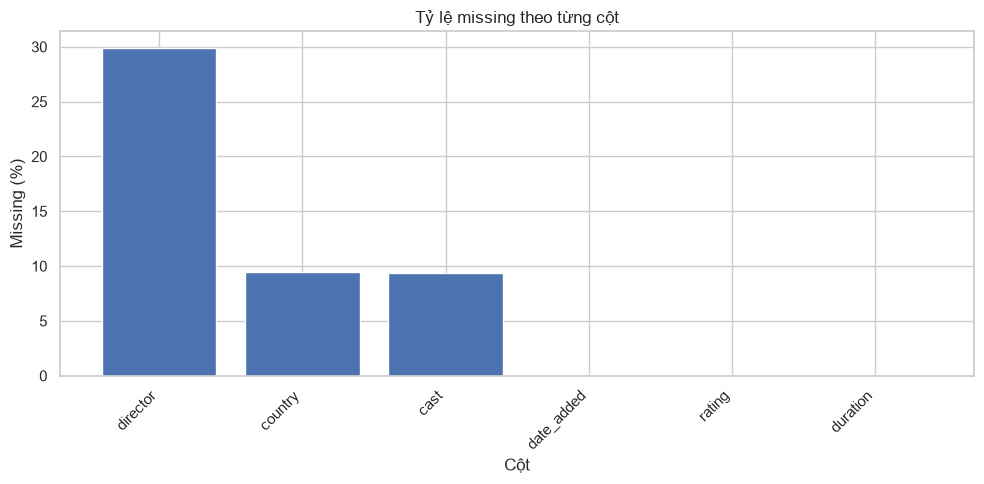

In [13]:
plt.figure(figsize=(10, 5))
plt.bar(missing_df.index, missing_df["missing_pct"])
plt.title("Tỷ lệ missing theo từng cột")
plt.xlabel("Cột")
plt.ylabel("Missing (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Phần 2 — Data Cleaning & Feature Engineering (**3,5 đ**)


### Câu 2.1 — tạo bản sao (**0,2 đ**)

Tạo bản sao từ df, gán vào df_clean.


In [14]:
df_clean = df.copy()

### Câu 2.2 — Cột phân loại đang thiếu (**0,3 đ**)

Kiểu phân loại (Category/Qualitative) có cột nào đang thiếu dữ liệu không?


In [15]:
categorical_cols = df_clean.select_dtypes(include=["object", "category"]).columns
categorical_missing = df_clean[categorical_cols].isna().sum()
categorical_missing = categorical_missing[categorical_missing > 0].sort_values(ascending=False)

print("Các cột phân loại đang thiếu:")
print(categorical_missing)

Các cột phân loại đang thiếu:
director      2634
country        831
cast           825
date_added      10
rating           4
duration         3
dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_9956\1332472373.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=["object", "category"]).columns


### Câu 2.3 — Xóa hay impute (**1,0 đ**)

Nếu thiếu:
- Có nên xóa không? Tại sao? Thực thi lệnh.
- Nếu không xóa thì impute dữ liệu gì, tại sao? Thực thi lệnh.


In [16]:
# Với dữ liệu phân loại, giữ lại các dòng có thể sử dụng và thay missing
# bằng nhãn "Unknown" giúp không làm mất dữ liệu và không áp đặt một nhóm phổ biến.
for col in categorical_missing.index:
    df_clean[col] = df_clean[col].fillna("Unknown")

print("Missing còn lại sau khi xử lý các cột phân loại:")
print(df_clean.isna().sum().sort_values(ascending=False).head(10))

Missing còn lại sau khi xử lý các cột phân loại:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
dtype: int64


### Câu 2.4 — Đổi date_added sang datetime (**0,5 đ**)

Chuyển cột date_added sang datetime.
- Lưu ý: Ép về str, xóa khoảng trắng, ô không parse được dùng NaT (errors="coerce").


In [17]:
df_clean["date_added"] = pd.to_datetime(
    df_clean["date_added"].astype(str).str.strip(),
    errors="coerce"
)

### Câu 2.5 — Kiểm tra date_added sau khi đổi (**0,2 đ**)

In dtype và 5 dòng cột date_added.


In [18]:
print("dtype:", df_clean["date_added"].dtype)
print(df_clean["date_added"].head())

dtype: datetime64[us]
0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]


### Câu 2.6 — Tạo year_added, month_added (**0,4 đ**)

Từ date_added, tạo 2 cột mới:
- year_added: năm
- month_added: tên tháng


In [19]:
df_clean["year_added"] = df_clean["date_added"].dt.year
df_clean["month_added"] = df_clean["date_added"].dt.month_name()

print(df_clean[["date_added", "year_added", "month_added"]].head())

  date_added  year_added month_added
0 2021-09-25      2021.0   September
1 2021-09-24      2021.0   September
2 2021-09-24      2021.0   September
3 2021-09-24      2021.0   September
4 2021-09-24      2021.0   September


### Câu 2.7 — primary_country (**0,4 đ**)

Tạo cột primary_country, lấy quốc gia đầu tiên trong country.
Ví dụ: India, United States -> India


In [20]:
df_clean["primary_country"] = (
    df_clean["country"]
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
)
df_clean["primary_country"] = df_clean["primary_country"].replace({"nan": "Unknown", "": "Unknown"})

### Câu 2.8 — primary_genre (**0,3 đ**)

Tạo cột primary_genre, lấy thể loại đầu tiên trong listed_in.
Ví dụ: Dramas, International Movies -> Dramas


In [21]:
df_clean["primary_genre"] = (
    df_clean["listed_in"]
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
)

### Câu 2.9 — Tách duration 

Cột duration đang là chữ lẫn số (ví dụ 90 min, 2 Seasons).
Tách làm 2 cột: duration_int (số) và duration_unit (đơn vị).

Gợi ý: str.extract lấy số, str.extract lấy chữ.


In [22]:
df_clean["duration_int"] = pd.to_numeric(
    df_clean["duration"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)
df_clean["duration_unit"] = (
    df_clean["duration"].astype(str).str.extract(r"([A-Za-z]+)")[0]
)

### Câu 2.10 — Kiểm tra cột mới (**0,1 đ**)

In 5 dòng đầu các cột vừa tạo: type, year_added, primary_country, primary_genre, duration_int, duration_unit.


In [23]:
cols_new = [
    "type", "year_added", "primary_country",
    "primary_genre", "duration_int", "duration_unit"
]
df_clean[cols_new].head()

,type,year_added,primary_country,primary_genre,duration_int,duration_unit
0,Movie,2021.0,United States,Documentaries,90.0,min
1,TV Show,2021.0,South Africa,International TV Shows,2.0,Seasons
2,TV Show,2021.0,Unknown,Crime TV Shows,1.0,Season
3,TV Show,2021.0,Unknown,Docuseries,1.0,Season
4,TV Show,2021.0,India,International TV Shows,2.0,Seasons


# Phần 3 — EDA (**3,0 đ**)

## 3.1 Univariate analysis


### Câu 3.1 — Mô tả cột Numeric (**0,2 đ**)

Mô tả các cột Numeric sau khi clean (release_year, year_added, duration_int).


In [24]:
df_clean[["release_year", "year_added", "duration_int"]].describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,8807.0,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
year_added,8797.0,2018.871888,1.574243,2008.0,2018.0,2019.0,2020.0,2021.0
duration_int,8804.0,69.846888,50.814828,1.0,2.0,88.0,106.0,312.0


### Câu 3.2 — Đếm Movie và TV Show (**0,2 đ**)

Đếm số lượng Movie và TV Show. In thêm % mỗi loại, làm tròn 1 chữ số thập phân.


In [25]:
type_counts = df_clean["type"].value_counts()
type_pct = (type_counts / len(df_clean) * 100).round(1)

print("Số lượng:")
print(type_counts)
print("\nTỷ lệ (%):")
print(type_pct)

Số lượng:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Tỷ lệ (%):
type
Movie      69.6
TV Show    30.4
Name: count, dtype: float64


### Câu 3.3 — Barplot type (**0,3 đ**)

Vẽ barplot số lượng Movie và TV Show. Có title, nhãn trục, hiện số trên cột.


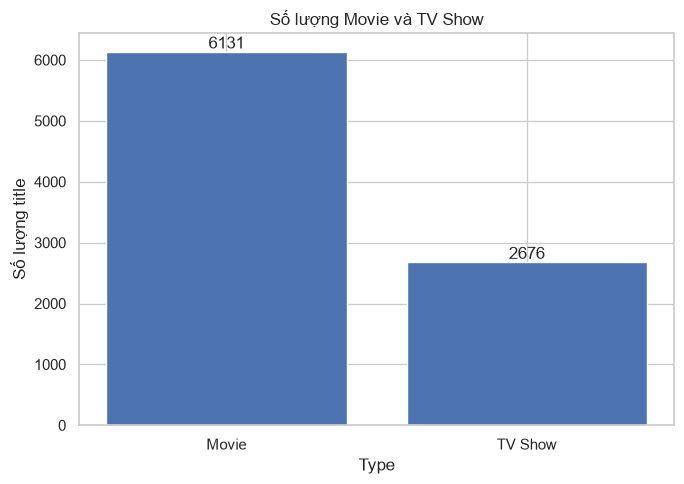

In [26]:
plt.figure(figsize=(7, 5))
bars = plt.bar(type_counts.index, type_counts.values)
plt.title("Số lượng Movie và TV Show")
plt.xlabel("Type")
plt.ylabel("Số lượng title")
plt.bar_label(bars, fmt="%d")
plt.tight_layout()
plt.show()

### Câu 3.4 — Nhận xét barplot type (**0,2 đ**)

Nhận xét barplot type (2–3 câu, dựa trên số vừa in):
- Loại nào nhiều hơn? Chiếm khoảng bao nhiêu %?
- Catalog Netflix nghiêng phim hay series?


In [27]:
movie_pct = type_pct.get("Movie", 0)
tv_pct = type_pct.get("TV Show", 0)
more_type = type_counts.idxmax()

print(
    f"{more_type} là loại có số lượng nhiều hơn, chiếm khoảng "
    f"{type_pct[more_type]:.1f}% tổng số title."
)
print(
    f"Catalog nghiêng về {more_type.lower()}, với Movie khoảng {movie_pct:.1f}% "
    f"và TV Show khoảng {tv_pct:.1f}%."
)

Movie là loại có số lượng nhiều hơn, chiếm khoảng 69.6% tổng số title.
Catalog nghiêng về movie, với Movie khoảng 69.6% và TV Show khoảng 30.4%.


### Câu 3.5 — Barplot rating (**0,3 đ**)



Content rating là gì?

Content rating = xếp hạng độ tuổi / đối tượng khán giả của phim và TV show trên Netflix.

| Rating | Ý nghĩa |
|---|---|
| TV-MA | Người lớn, nội dung mạnh |
| TV-14 | Từ khoảng 14 tuổi trở lên |
| TV-PG | Trẻ xem được nếu có hướng dẫn phụ huynh |
| PG-13 | Phim điện ảnh, dưới 13 nên có người lớn đi cùng |
| R | Restricted, dưới 17 cần người lớn |
| TV-Y / TV-G | Trẻ nhỏ / mọi lứa tuổi |




Đếm số lượng theo rating, lấy top 12. Vẽ barplot. Có title, nhãn trục.
Làm tương tự barplot type ở trên. Không copy insight có sẵn.

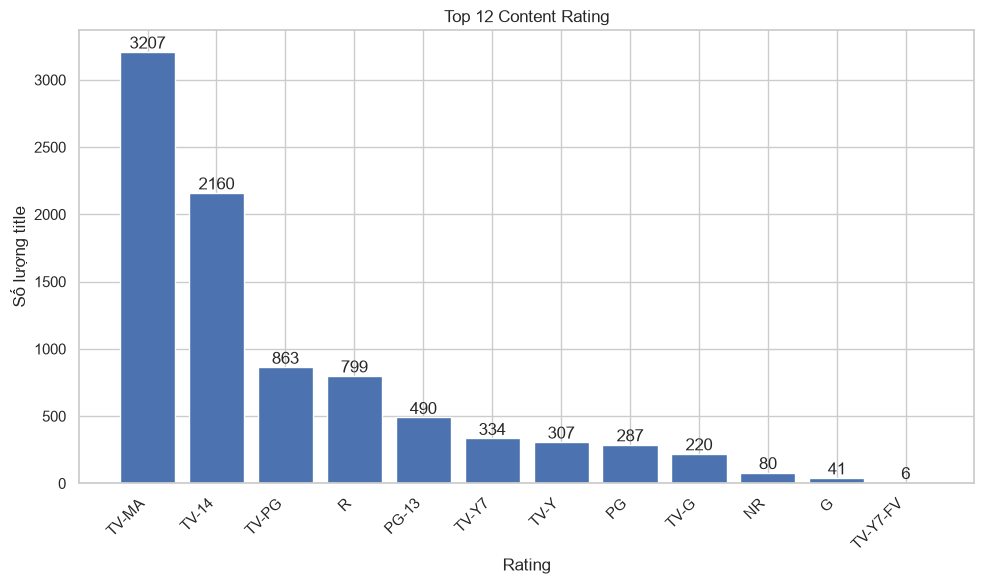

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Name: count, dtype: int64


In [28]:
rating_counts = df_clean["rating"].value_counts().head(12)

plt.figure(figsize=(10, 6))
bars = plt.bar(rating_counts.index, rating_counts.values)
plt.title("Top 12 Content Rating")
plt.xlabel("Rating")
plt.ylabel("Số lượng title")
plt.xticks(rotation=45, ha="right")
plt.bar_label(bars, fmt="%d")
plt.tight_layout()
plt.show()

print(rating_counts)

### Câu 3.6 — Nhận xét barplot rating (**0,2 đ**)

Nhận xét (dựa trên số vừa vẽ):
- Rating nào nhiều nhất? Khoảng bao nhiêu title?
- Catalog nghiêng người lớn, teen, hay trẻ em?


In [29]:
top_rating = rating_counts.idxmax()
top_rating_n = int(rating_counts.max())

adult_ratings = {"TV-MA", "R"}
teen_ratings = {"TV-14", "PG-13", "TV-PG", "TV-Y7", "TV-Y7-FV"}
child_ratings = {"TV-Y", "TV-G", "G", "PG"}

adult_n = rating_counts[rating_counts.index.isin(adult_ratings)].sum()
teen_n = rating_counts[rating_counts.index.isin(teen_ratings)].sum()
child_n = rating_counts[rating_counts.index.isin(child_ratings)].sum()

print(f"Rating phổ biến nhất là {top_rating}, khoảng {top_rating_n} title.")
print(
    f"Trong top 12 rating, nhóm người lớn (TV-MA/R) có {adult_n} title, "
    f"nhóm teen có {teen_n} title và nhóm trẻ em/gia đình có {child_n} title."
)
print("Vì vậy, trong top 12 rating, số lượng nghiêng về nhóm người lớn.")

Rating phổ biến nhất là TV-MA, khoảng 3207 title.
Trong top 12 rating, nhóm người lớn (TV-MA/R) có 4006 title, nhóm teen có 3853 title và nhóm trẻ em/gia đình có 855 title.
Vì vậy, trong top 12 rating, số lượng nghiêng về nhóm người lớn.


### Câu 3.7 — Outlier duration phim (**0,5 đ**)

Cột: duration_int, chỉ các dòng Movie (đơn vị phút). Không dùng TV Show.

Yêu cầu:
1. Boxplot duration phim.
2. Tính IQR: Q1, Q3. 
3. Đếm số điểm ngoài fence.


Q1 = 87.00
Q3 = 114.00
IQR = 27.00
Lower fence = 46.50
Upper fence = 154.50
Số điểm ngoài fence = 450


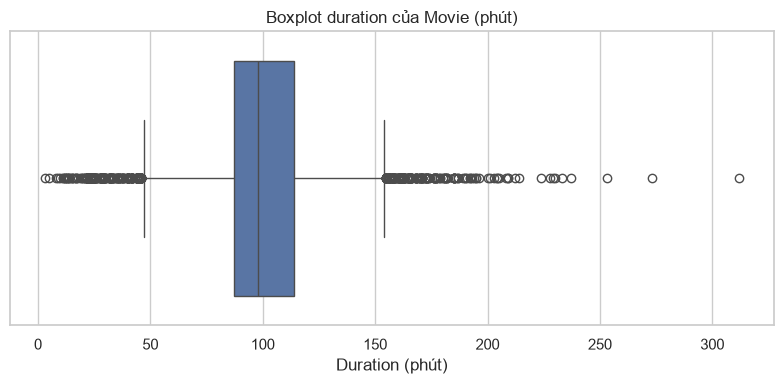

In [30]:
movie_duration = df_clean.loc[
    (df_clean["type"] == "Movie") & (df_clean["duration_unit"] == "min"),
    "duration_int"
].dropna()

Q1 = movie_duration.quantile(0.25)
Q3 = movie_duration.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outlier_mask = (movie_duration < lower_fence) | (movie_duration > upper_fence)
n_outliers = int(outlier_mask.sum())

print(f"Q1 = {Q1:.2f}")
print(f"Q3 = {Q3:.2f}")
print(f"IQR = {IQR:.2f}")
print(f"Lower fence = {lower_fence:.2f}")
print(f"Upper fence = {upper_fence:.2f}")
print(f"Số điểm ngoài fence = {n_outliers}")

plt.figure(figsize=(8, 4))
sns.boxplot(x=movie_duration)
plt.title("Boxplot duration của Movie (phút)")
plt.xlabel("Duration (phút)")
plt.tight_layout()
plt.show()

### Câu 3.8 — Quyết định outlier tiếp câu 3.7 (**0,3 đ**)

Quyết định keep / cap / remove outlier của cột này? Vì sao? 


IQR và clip khác nhau ở điểm nào? (**+0,5 đ**)


In [31]:
print("Quyết định: KEEP outlier.")
print(
    "Lý do: duration của phim có thể khác nhau tự nhiên; các phim rất dài "
    "không nhất thiết là lỗi dữ liệu. Xóa hoặc cap có thể làm mất thông tin."
)
print(
    "IQR là thước đo độ phân tán giữa Q1 và Q3 và được dùng để xác định "
    "fence/outlier. Clip là thao tác giới hạn các giá trị vượt ngưỡng về "
    "một mức biên, nên clip làm thay đổi dữ liệu còn IQR chủ yếu dùng để phát hiện."
)

Quyết định: KEEP outlier.
Lý do: duration của phim có thể khác nhau tự nhiên; các phim rất dài không nhất thiết là lỗi dữ liệu. Xóa hoặc cap có thể làm mất thông tin.
IQR là thước đo độ phân tán giữa Q1 và Q3 và được dùng để xác định fence/outlier. Clip là thao tác giới hạn các giá trị vượt ngưỡng về một mức biên, nên clip làm thay đổi dữ liệu còn IQR chủ yếu dùng để phát hiện.


## 3.2 Multivariate analysis


### Câu 3.9 — Correlation (**0,5 đ**)

Corr các cột release_year, year_added, duration_int.

Gợi ý: duration_int Movie. Nên lọc type == Movie trước khi corr.

Yêu cầu:
1. In ma trận corr.
2. Heatmap, có annot.


              release_year  year_added  duration_int
release_year         1.000       0.039        -0.206
year_added           0.039       1.000         0.124
duration_int        -0.206       0.124         1.000


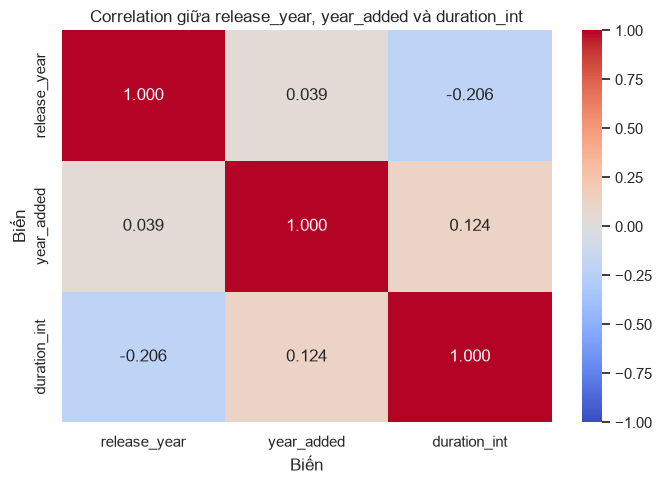

In [32]:
movie_df = df_clean.loc[
    (df_clean["type"] == "Movie") & (df_clean["duration_unit"] == "min"),
    ["release_year", "year_added", "duration_int"]
].dropna()

corr = movie_df.corr()
print(corr.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation giữa release_year, year_added và duration_int")
plt.xlabel("Biến")
plt.ylabel("Biến")
plt.tight_layout()
plt.show()

### Câu 3.10 — Nhận xét corr (**0,3 đ**)

Nhận xét cặp tương quan nổi bật (dương/âm, mạnh/yếu). Ý nghĩa 1 câu.


In [33]:
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()

if len(pairs):
    pair = pairs.abs().idxmax()
    value = pairs.loc[pair]
    strength = "mạnh" if abs(value) >= 0.7 else ("vừa" if abs(value) >= 0.4 else "yếu")
    direction = "dương" if value > 0 else "âm"
    if set(pair) == {"release_year", "duration_int"} and value < 0:
        relation = "khi release_year tăng thì duration_int có xu hướng giảm nhẹ"
    else:
        relation = "hai biến có xu hướng thay đổi theo dấu của hệ số corr"
    print(
        f"Cặp tương quan nổi bật nhất là {pair[0]} và {pair[1]}, "
        f"corr = {value:.3f}, tương quan {direction} và {strength}."
    )
    print(f"Ý nghĩa: {relation}. Tương quan không tự chứng minh quan hệ nhân quả.")

Cặp tương quan nổi bật nhất là release_year và duration_int, corr = -0.206, tương quan âm và yếu.
Ý nghĩa: khi release_year tăng thì duration_int có xu hướng giảm nhẹ. Tương quan không tự chứng minh quan hệ nhân quả.


# Phần 4 — Summary và insights (**1,0 đ**)

Điền vào chỗ trống. Lấy số từ output đã chạy. Không bịa số.


### Câu 4.1–4.3

**(1) Chất lượng dữ liệu — 0,3 đ**
Toàn bộ dataset thiếu khoảng ...... %. Cột thiếu nhiều nhất là ...... (khoảng ...... %).
Cột nhóm em fill bằng ...... .

**(2) Catalog — 0,4 đ**
Movie chiếm khoảng ...... %, TV Show khoảng ...... %.
Rating phổ biến nhất: ...... .

**(3) Chọn đúng 1 trong 2 — 0,3 đ**
Outlier: cột duration_int (chỉ Movie, phút) có / không có outlier rõ. Em chọn keep / cap / remove vì ......
hoặc
Tương quan: cặp ...... và ...... có corr khoảng ...... (dương/âm, mạnh/yếu). Ý nghĩa: ......


In [34]:
total_missing_original = int(df.isna().sum().sum())
total_cells_original = int(df.shape[0] * df.shape[1])
overall_missing_original = total_missing_original / total_cells_original * 100

missing_original = df.isna().sum().sort_values(ascending=False)
most_missing_col = missing_original.idxmax()
most_missing_pct = missing_original.max() / len(df) * 100

movie_pct = df_clean["type"].eq("Movie").mean() * 100
tv_pct = df_clean["type"].eq("TV Show").mean() * 100
top_rating = df_clean["rating"].value_counts().idxmax()

print(
    f"(1) Chất lượng dữ liệu — Toàn bộ dataset ban đầu thiếu khoảng "
    f"{overall_missing_original:.2f}%. Cột thiếu nhiều nhất là "
    f"{most_missing_col} (khoảng {most_missing_pct:.2f}%). "
    f"Các cột phân loại thiếu được fill bằng 'Unknown'."
)
print(
    f"(2) Catalog — Movie chiếm khoảng {movie_pct:.1f}%, "
    f"TV Show khoảng {tv_pct:.1f}%. Rating phổ biến nhất: {top_rating}."
)
print(
    f"(3) Outlier — duration_int (chỉ Movie, phút) có outlier theo quy tắc IQR; "
    f"em chọn KEEP vì các thời lượng cực trị có thể là giá trị thực tế và không nhất thiết là lỗi."
)

(1) Chất lượng dữ liệu — Toàn bộ dataset ban đầu thiếu khoảng 4.08%. Cột thiếu nhiều nhất là director (khoảng 29.91%). Các cột phân loại thiếu được fill bằng 'Unknown'.
(2) Catalog — Movie chiếm khoảng 69.6%, TV Show khoảng 30.4%. Rating phổ biến nhất: TV-MA.
(3) Outlier — duration_int (chỉ Movie, phút) có outlier theo quy tắc IQR; em chọn KEEP vì các thời lượng cực trị có thể là giá trị thực tế và không nhất thiết là lỗi.


# Encoding 


### Câu B1 — Encoding cột type (**+0,7 đ**)

Cột type nên dùng one-hot hay label? Vì sao? Viết code thực thi.


In [35]:
# type là biến phân loại không có thứ tự tự nhiên, nên dùng one-hot encoding.
type_encoded = pd.get_dummies(df_clean, columns=["type"], prefix="type", dtype=int)

print(type_encoded[["type_Movie", "type_TV Show"]].head())
print("Kích thước sau one-hot:", type_encoded.shape)

   type_Movie  type_TV Show
0           1             0
1           0             1
2           0             1
3           0             1
4           0             1
Kích thước sau one-hot: (8807, 19)


### Câu B2 — Encoding rating / primary_genre (**+0,8 đ**)

Cột rating hoặc primary_genre nên dùng loại nào? Vì sao? Viết code thực thi.


In [36]:
# rating/primary_genre có nhiều nhóm và không có thứ tự số tự nhiên.
# Với dữ liệu dạng category nhiều mức, one-hot phù hợp nếu dùng cho mô hình.
# Ở đây thực hiện one-hot cho rating.
rating_encoded = pd.get_dummies(
    df_clean, columns=["rating"], prefix="rating", dtype=int
)

print(rating_encoded.filter(regex=r"^rating_").head())
print("Số cột rating sau encoding:", len(rating_encoded.filter(regex=r"^rating_").columns))

   rating_66 min  rating_74 min  rating_84 min  rating_G  rating_NC-17  \
0              0              0              0         0             0   
1              0              0              0         0             0   
2              0              0              0         0             0   
3              0              0              0         0             0   
4              0              0              0         0             0   

   rating_NR  rating_PG  rating_PG-13  rating_R  rating_TV-14  rating_TV-G  \
0          0          0             1         0             0            0   
1          0          0             0         0             0            0   
2          0          0             0         0             0            0   
3          0          0             0         0             0            0   
4          0          0             0         0             0            0   

   rating_TV-MA  rating_TV-PG  rating_TV-Y  rating_TV-Y7  rating_TV-Y7-FV  \
0        